# 📊 Monthly Expense – Full Preprocessing Pipeline (v2)

**Purpose:** Clean, transform, engineer features, and save processed outputs from the raw expense dataset.

**Input:** `data/raw/expenses_income_summary_1.csv`

**Outputs:**
- `data/processed/monthly_expense.csv`
- `data/processed/weekly_expense.csv`
- `data/processed/train.csv` / `data/processed/test.csv`
- `data/processed/features_monthly.csv`
- `data/processed/features_weekly.csv`

## ✅ Step 1: Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# ─── Paths ───────────────────────────────────────────────
RAW_PATH      = 'data/raw/expenses_income_summary_1.csv'
PROCESSED_DIR = 'data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# ─── Config ──────────────────────────────────────────────
TEST_MONTHS   = 6        # last N months held out as test set
IQR_FACTOR    = 3.0      # outlier capping threshold (conservative)

print('✅ Libraries loaded. Processed dir ready.')

✅ Libraries loaded. Processed dir ready.


## ✅ Step 2: Load Raw Data + Initial Inspection

In [3]:
df_raw = pd.read_csv("C:/Users/vetch/Downloads/programming/monthy_expense/data/raw/expenses_income_summary_1.csv")

print(f'📦 Raw shape : {df_raw.shape}')
print(f'\n📋 Columns  : {df_raw.columns.tolist()}')
print(f'\n🔍 Dtypes:\n{df_raw.dtypes}')
print(f'\n❓ Null counts:\n{df_raw.isnull().sum()}')
print(f'\n📄 First 5 rows:')
df_raw.head()

📦 Raw shape : (1500, 8)

📋 Columns  : ['Date', 'Time', 'Title', 'Category', 'account', 'Amount', 'Currency', 'Type']

🔍 Dtypes:
Date        object
Time        object
Title       object
Category    object
account     object
Amount      object
Currency    object
Type        object
dtype: object

❓ Null counts:
Date          0
Time          0
Title        30
Category    204
account       0
Amount        0
Currency      0
Type          0
dtype: int64

📄 First 5 rows:


,Date,Time,Title,Category,account,Amount,Currency,Type
0,01/02/20,56:59.7,Karthik,Bills & Fees,Savings Bank,45,INR,EXPENSE
1,01/02/20,09:56.0,Juice,Food & Drinks,Cash,40,INR,EXPENSE
2,01/04/20,25:21.6,Tire,Transport,Cash,10,INR,EXPENSE
3,01/05/20,57:24.9,Baba,Bills & Fees,Savings Bank,200,INR,EXPENSE
4,01/13/20,09:08.5,Reward,Bills & Fees,Salary Bank,4,INR,INCOME


## ✅ Step 3: Column Normalization

In [4]:
df = df_raw.copy()

# Lowercase + strip whitespace from all column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Strip whitespace from all string values
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print(f'✅ Normalized columns: {df.columns.tolist()}')

✅ Normalized columns: ['date', 'time', 'title', 'category', 'account', 'amount', 'currency', 'type']


## ✅ Step 4: Date Parsing

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%y', errors='coerce')

bad_dates = df['date'].isna().sum()
print(f'📅 Date range  : {df["date"].min()} → {df["date"].max()}')
print(f'❌ Unparseable dates: {bad_dates}')

if bad_dates > 0:
    print('\n⚠️  Rows with bad dates (will be dropped):')
    print(df[df['date'].isna()][['date', 'title', 'amount']].head(10))

📅 Date range  : 2020-01-02 00:00:00 → 2024-12-29 00:00:00
❌ Unparseable dates: 0


## ✅ Step 5: Amount Cleaning (Single Clean Block)

In [6]:
df['amount'] = (
    df['amount']
    .astype(str)
    .str.replace(',', '', regex=False)       # remove thousand separators
    .str.replace('₹', '', regex=False)       # remove rupee symbol
    .str.replace('INR', '', regex=False)     # remove currency text if any
    .str.strip()
)

# Catch corrupted values like '613.0.0' by keeping only valid numeric strings
df['amount'] = df['amount'].str.extract(r'^(\d+\.?\d*)')[0]
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

print(f'💰 Amount dtype  : {df["amount"].dtype}')
print(f'❌ Null amounts   : {df["amount"].isna().sum()}')
print(f'📊 Amount stats:\n{df["amount"].describe()}')

💰 Amount dtype  : float64
❌ Null amounts   : 0
📊 Amount stats:
count     1500.000000
mean       358.756280
std       1829.465607
min          0.000000
25%         20.000000
50%         35.000000
75%        100.000000
max      22700.000000
Name: amount, dtype: float64


## ✅ Step 6: Filter EXPENSE Rows Only

In [7]:
n_before = len(df)

if 'type' in df.columns:
    df['type'] = df['type'].str.lower()
    type_counts = df['type'].value_counts()
    print(f'📊 Type distribution:\n{type_counts}')
    df = df[df['type'] == 'expense'].copy()

print(f'\n✅ Rows before type filter : {n_before}')
print(f'✅ Rows after  type filter : {len(df)} (EXPENSE only)')

📊 Type distribution:
type
expense     1316
income       126
transfer      58
Name: count, dtype: int64

✅ Rows before type filter : 1500
✅ Rows after  type filter : 1316 (EXPENSE only)


## ✅ Step 7: Drop Nulls & Invalid Amounts

In [8]:
n_before = len(df)

df = df.dropna(subset=['date', 'amount'])
df = df[df['amount'] > 0]

print(f'✅ Rows before dropna/filter : {n_before}')
print(f'✅ Rows after  dropna/filter : {len(df)}')

✅ Rows before dropna/filter : 1316
✅ Rows after  dropna/filter : 1316


## ✅ Step 8: Outlier Detection & Capping (IQR Method)

In [10]:
Q1  = df['amount'].quantile(0.25)
Q3  = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - IQR_FACTOR * IQR)
upper_bound = Q3 + IQR_FACTOR * IQR

outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
print(f'📊 IQR bounds  : [{lower_bound:.2f}, {upper_bound:.2f}]')
print(f'⚠️  Outliers found : {len(outliers)} rows')
if len(outliers) > 0:
    print(outliers[['date', 'title', 'category', 'amount']].sort_values('amount', ascending=False).head(10))

# Cap (clip) outliers rather than drop them
df['amount'] = df['amount'].clip(lower=lower_bound, upper=upper_bound)
print(f'\n✅ Outliers capped. Amount range now: [{df["amount"].min():.2f}, {df["amount"].max():.2f}]')

📊 IQR bounds  : [0.00, 340.00]
⚠️  Outliers found : 0 rows

✅ Outliers capped. Amount range now: [0.90, 340.00]


## ✅ Step 9: Category Null Handling

In [11]:
cat_nulls = df['category'].isna().sum()
print(f'📂 Category nulls before : {cat_nulls} ({cat_nulls/len(df)*100:.1f}%)')

df['category'] = df['category'].fillna('Unknown')

print(f'✅ Category nulls after  : {df["category"].isna().sum()}')
print(f'\n📊 Category distribution:\n{df["category"].value_counts().head(10)}')

📂 Category nulls before : 99 (7.5%)
✅ Category nulls after  : 0

📊 Category distribution:
category
Transport        535
Food & Drinks    366
Bills & Fees     316
Unknown           99
Name: count, dtype: int64


## ✅ Step 10: Drop Unused Columns

In [12]:
# 'time' is malformed (e.g., 56:59.7), 'currency' is all INR, 'type' is now redundant
cols_to_drop = [c for c in ['time', 'currency', 'type'] if c in df.columns]

df = df.drop(columns=cols_to_drop)

print(f'🗑️  Dropped columns : {cols_to_drop}')
print(f'✅ Remaining columns: {df.columns.tolist()}')

🗑️  Dropped columns : ['time', 'currency', 'type']
✅ Remaining columns: ['date', 'title', 'category', 'account', 'amount']


## ✅ Step 11: Sort by Date + Deduplication Check

In [13]:
df = df.sort_values('date').reset_index(drop=True)

# Check for exact duplicates (same date + title + amount)
dup_mask = df.duplicated(subset=['date', 'title', 'amount'], keep='first')
n_dups = dup_mask.sum()
print(f'🔁 Duplicate rows found : {n_dups}')

if n_dups > 0:
    print('Removing duplicates...')
    df = df[~dup_mask].reset_index(drop=True)

print(f'✅ Final clean row count : {len(df)}')
print(f'📅 Date range: {df["date"].min().date()} → {df["date"].max().date()}')

🔁 Duplicate rows found : 14
Removing duplicates...
✅ Final clean row count : 1302
📅 Date range: 2020-01-02 → 2024-12-29


## ✅ Step 12: Gap Detection & Flagging

📅 Total months in range  : 60
⚠️  Months with zero data  : 0


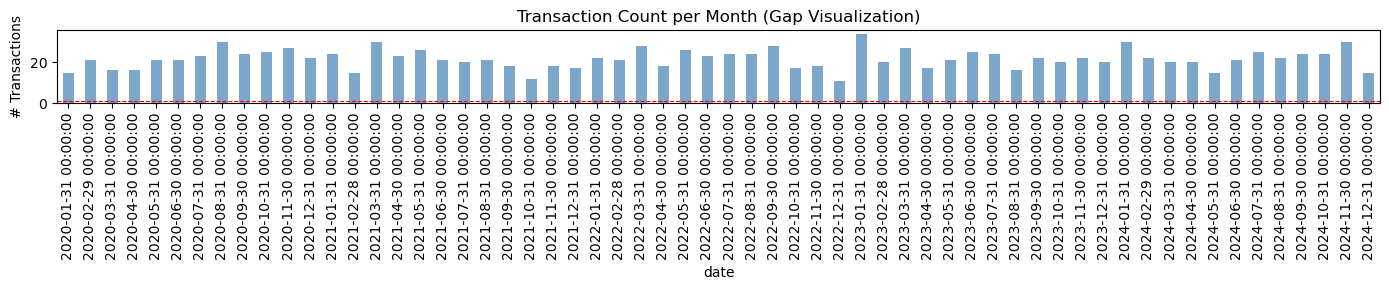

✅ Gap visualization saved.


In [15]:
# Check for months that have no transactions at all
monthly_counts = df.set_index('date').resample('M')['amount'].count()
missing_months = monthly_counts[monthly_counts == 0]

print(f'📅 Total months in range  : {len(monthly_counts)}')
print(f'⚠️  Months with zero data  : {len(missing_months)}')

if len(missing_months) > 0:
    print(f'\n🕳️  Gap months:')
    print(missing_months.index.strftime('%Y-%m').tolist())

# Visualize data density
fig, ax = plt.subplots(figsize=(14, 3))
monthly_counts.plot(ax=ax, kind='bar', color='steelblue', alpha=0.7)
ax.set_title('Transaction Count per Month (Gap Visualization)')
ax.set_ylabel('# Transactions')
ax.axhline(1, color='red', linestyle='--', linewidth=0.8, label='Zero threshold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/gap_visualization.png', dpi=100)
plt.show()
print('✅ Gap visualization saved.')

## ✅ Step 13: Aggregate → Weekly & Monthly

In [17]:
# ─── Monthly ─────────────────────────────────────────────
monthly = (
    df.set_index('date')['amount']
    .resample('M')          # 'ME' = Month End (fixed deprecation warning)
    .sum()
    .rename('amount')
    .reset_index()
)
# Remove months with zero spend (pure gap months)
monthly = monthly[monthly['amount'] > 0].reset_index(drop=True)

# ─── Weekly ──────────────────────────────────────────────
weekly = (
    df.set_index('date')['amount']
    .resample('W')           # weekly
    .sum()
    .rename('amount')
    .reset_index()
)
weekly = weekly[weekly['amount'] > 0].reset_index(drop=True)

print(f'📅 Monthly data points : {len(monthly)}')
print(f'📅 Weekly  data points : {len(weekly)}')
print(f'\n🗓️  Monthly head:\n{monthly.head()}')
print(f'\n🗓️  Weekly head:\n{weekly.head()}')

📅 Monthly data points : 60
📅 Weekly  data points : 256

🗓️  Monthly head:
        date  amount
0 2020-01-31  1855.0
1 2020-02-29  3077.0
2 2020-03-31  1413.9
3 2020-04-30  1866.0
4 2020-05-31  3407.5

🗓️  Weekly head:
        date  amount
0 2020-01-05   295.0
1 2020-01-19   470.0
2 2020-01-26   668.0
3 2020-02-02   472.0
4 2020-02-09  1004.0


## ✅ Step 14: Feature Engineering

In [18]:
def add_features(ts_df, freq='monthly'):
    """Add time-based and lag/rolling features to a time series DataFrame."""
    d = ts_df.copy()
    d = d.set_index('date').sort_index()

    # ── Calendar features ──────────────────────────────
    d['month']       = d.index.month
    d['quarter']     = d.index.quarter
    d['year']        = d.index.year
    if freq == 'weekly':
        d['week_of_year']  = d.index.isocalendar().week.astype(int)
        d['week_of_month'] = (d.index.day - 1) // 7 + 1

    # ── Lag features ───────────────────────────────────
    lags = [1, 2, 3] if freq == 'monthly' else [1, 2, 4]
    for lag in lags:
        d[f'lag_{lag}'] = d['amount'].shift(lag)

    # ── Rolling statistics ──────────────────────────────
    windows = [3, 6] if freq == 'monthly' else [4, 8, 12]
    for w in windows:
        d[f'rolling_mean_{w}'] = d['amount'].shift(1).rolling(window=w).mean()
        d[f'rolling_std_{w}']  = d['amount'].shift(1).rolling(window=w).std()

    # ── Percent change ─────────────────────────────────
    d['pct_change']  = d['amount'].pct_change()

    # Drop rows that have NaN from lag/rolling (head rows)
    d = d.dropna()
    return d.reset_index()

feat_monthly = add_features(monthly, freq='monthly')
feat_weekly  = add_features(weekly,  freq='weekly')

print(f'✅ Monthly feature set : {feat_monthly.shape} | columns: {feat_monthly.columns.tolist()}')
print(f'✅ Weekly  feature set : {feat_weekly.shape}  | columns: {feat_weekly.columns.tolist()}')

✅ Monthly feature set : (54, 13) | columns: ['date', 'amount', 'month', 'quarter', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'pct_change']
✅ Weekly  feature set : (244, 17)  | columns: ['date', 'amount', 'month', 'quarter', 'year', 'week_of_year', 'week_of_month', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'pct_change']


## ✅ Step 15: Train / Test Split + Save All Outputs

In [19]:
# ─── Train/Test split on monthly data ────────────────────
split_idx_m = len(monthly) - TEST_MONTHS
train_m     = monthly.iloc[:split_idx_m]
test_m      = monthly.iloc[split_idx_m:]

# Weekly split (last 4*TEST_MONTHS weeks as test)
split_idx_w = len(weekly) - (TEST_MONTHS * 4)
train_w     = weekly.iloc[:split_idx_w]
test_w      = weekly.iloc[split_idx_w:]

print(f'📊 Monthly → Train: {len(train_m)} | Test: {len(test_m)}')
print(f'📊 Weekly  → Train: {len(train_w)} | Test: {len(test_w)}')

# ─── Save all processed files ─────────────────────────────
monthly.to_csv(          f'{PROCESSED_DIR}/monthly_expense.csv',   index=False)
weekly.to_csv(           f'{PROCESSED_DIR}/weekly_expense.csv',    index=False)
train_m.to_csv(          f'{PROCESSED_DIR}/train_monthly.csv',     index=False)
test_m.to_csv(           f'{PROCESSED_DIR}/test_monthly.csv',      index=False)
train_w.to_csv(          f'{PROCESSED_DIR}/train_weekly.csv',      index=False)
test_w.to_csv(           f'{PROCESSED_DIR}/test_weekly.csv',       index=False)
feat_monthly.to_csv(     f'{PROCESSED_DIR}/features_monthly.csv',  index=False)
feat_weekly.to_csv(      f'{PROCESSED_DIR}/features_weekly.csv',   index=False)

print(f'\n✅ All files saved to: {PROCESSED_DIR}/')
print('   → monthly_expense.csv')
print('   → weekly_expense.csv')
print('   → train_monthly.csv / test_monthly.csv')
print('   → train_weekly.csv  / test_weekly.csv')
print('   → features_monthly.csv')
print('   → features_weekly.csv')
print('   → gap_visualization.png')

📊 Monthly → Train: 54 | Test: 6
📊 Weekly  → Train: 232 | Test: 24

✅ All files saved to: data/processed/
   → monthly_expense.csv
   → weekly_expense.csv
   → train_monthly.csv / test_monthly.csv
   → train_weekly.csv  / test_weekly.csv
   → features_monthly.csv
   → features_weekly.csv
   → gap_visualization.png


## ✅ Step 16: Final Summary Visualization

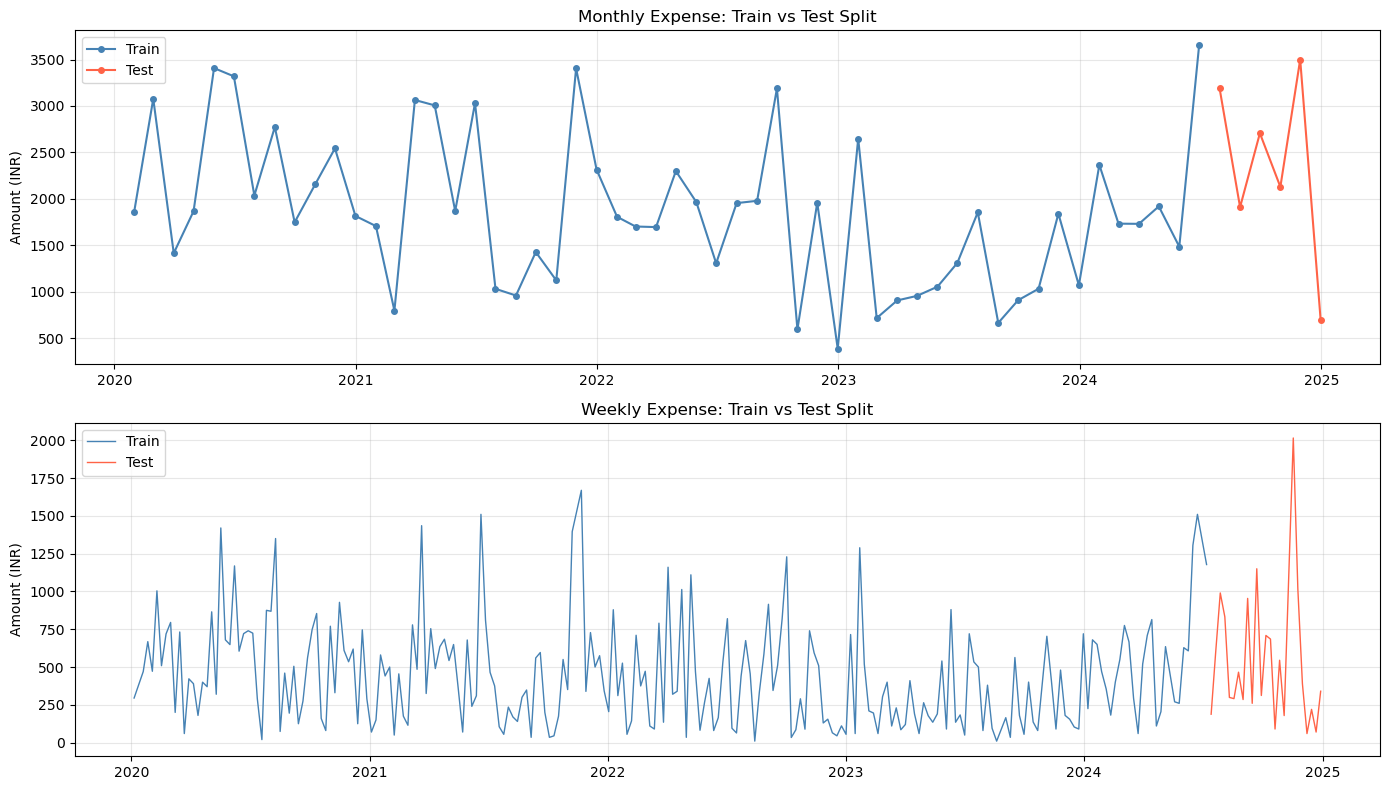


🎉 Preprocessing complete! All outputs saved.


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Monthly plot
axes[0].plot(train_m['date'], train_m['amount'], label='Train', color='steelblue', marker='o', markersize=4)
axes[0].plot(test_m['date'],  test_m['amount'],  label='Test',  color='tomato',    marker='o', markersize=4)
axes[0].set_title('Monthly Expense: Train vs Test Split')
axes[0].set_ylabel('Amount (INR)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weekly plot
axes[1].plot(train_w['date'], train_w['amount'], label='Train', color='steelblue', linewidth=1)
axes[1].plot(test_w['date'],  test_w['amount'],  label='Test',  color='tomato',    linewidth=1)
axes[1].set_title('Weekly Expense: Train vs Test Split')
axes[1].set_ylabel('Amount (INR)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/train_test_split.png', dpi=120)
plt.show()

print('\n🎉 Preprocessing complete! All outputs saved.')